In [615]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    WhiteKernel,
    RBF,
    Product,
    Kernel,
)
import pandas as pd
from typing import Optional
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from helpers import processing
import os
import joblib


class GaussianProcessFB:
    """
    Gaussian Process model for pressure drop and bed height predictions and uncertainty estimation.

    Attributes:
    ----------
        kernel: The kernel used for the Gaussian Process.
        scaler: A dictionary containing scalers for input and output data.
        data: A pandas DataFrame to store training data.
        model: The Gaussian Process Regressor model.
        target_columns: List of target variable column names.
        independent_columns: List of independent variable column names.
    """

    def __init__(
        self,
        model: Optional[GaussianProcessRegressor] = None,
        kernel: Optional[Kernel] = None,
        scaler: Optional[dict] = None,
        num_inputs=None,
    ):
        """
        Initializes the GaussianProcessFB with specified or default kernel and scaler.

        Parameters:
        ----------
            kernel: An optional kernel for the Gaussian Process. If None, a default kernel is used.
            scaler: An optional dictionary with 'input' and 'output' scalers. If None, StandardScaler is used for both.
            model: An optional GaussianProcessRegressor model. If None, a default model is created.
        """

        if kernel is not None:
            self.kernel = kernel
        else:
            # Default kernel components: RBF, WhiteKernel, and ConstantKernel
            self.kernel = Product(
                ConstantKernel(constant_value_bounds=(1e-5, 1e5)),
                RBF(
                    length_scale_bounds=(1e-5, 1e5),
                    length_scale=np.ones(num_inputs),
                ),
            ) + WhiteKernel(noise_level_bounds=(1e-5, 1e5))
        if scaler is not None:
            self.scaler = scaler
        else:
            # Default to StandardScaler for both input and output
            self.scaler = {
                "input": StandardScaler(),
                "output": StandardScaler(),
            }

        if model is not None:
            self.modelf = model
            self.kernel = self.modelf.kernel_
        else:
            # Default Gaussian Process Regressor with specified kernel
            self.modelf = GaussianProcessRegressor(
                kernel=self.kernel,
                n_restarts_optimizer=200,
                normalize_y=True,
                alpha=1e-10,
                # random_state=30,
            )

    def load(self, model: GaussianProcessRegressor, scaler: dict = None):
        """
        Loads a pre-trained Gaussian Process model and scalers.

        Parameters:
        ----------
            model: A pre-trained GaussianProcessRegressor model.
            scaler: A dictionary with 'input' and 'output' scalers.
        """

        self.modelf = model
        self.scaler = scaler
        if scaler is None:
            self.scaler = {
                "input": StandardScaler(),
                "output": StandardScaler(),
            }
        self.kernel = self.modelf.kernel_

    def save(self, name, incl_scaler: bool = False):
        """
        Saves the current Gaussian Process model and scalers.

        Returns:
        -------
            A GaussianProcessRegressor model
            A tuple containing the model and scalers if incl_scaler is True.
        """

        if not incl_scaler:
            joblib.dump(self.modelf, f"{name}.joblib")

        else:
            joblib.dump(self.modelf, f"{name}.joblib")
            joblib.dump(self.scaler, f"{name}_scaler.joblib")

    def fit(
        self,
        data: pd.DataFrame,
        target_columns: list,
        independent_columns: list,
    ):
        """
        Fits the Gaussian Process model to the provided data.

        Parameters:
        ----------
            data: A pandas DataFrame containing the training data.
            target_columns: List of column names for target variables.
            independent_columns: List of column names for independent variables.
        """

        self.data = data
        self.target_columns = target_columns
        self.independent_columns = independent_columns

        X = data[independent_columns].values
        y = data[target_columns].values

        if y.ndim == 1:
            y = y.reshape(-1, 1)

        # Scale input and output data
        X_scaled = self.scaler["input"].fit_transform(X)
        y_scaled = self.scaler["output"].fit_transform(y)

        # Fit the GP model
        self.modelf.fit(X_scaled, y_scaled)

    def predict(self, X: np.ndarray):
        """
        Predicts target variables for given input data using the trained GP model.

        Parameters:
        ----------
            X: A numpy array of input data.

        Returns:
        -------
            A tuple containing predicted values and standard deviations.
        """

        # Scale input data
        X_scaled = self.scaler["input"].transform(X)

        # Predict using the GP model
        y_pred_scaled, sigma_scaled = self.modelf.predict(X_scaled, return_std=True)
        if y_pred_scaled.ndim == 1:
            y_pred_scaled = y_pred_scaled.reshape(-1, 1)
            sigma_scaled = sigma_scaled.reshape(-1, 1)

        # Inverse scale the predictions
        y_pred = self.scaler["output"].inverse_transform(y_pred_scaled)
        sigma = sigma_scaled * self.scaler["output"].scale_

        return y_pred, sigma

    def get_hyperparameters(self):
        """
        Retrieves the hyperparameters of the trained GP model.

        Returns:
        -------
            A dictionary of hyperparameters.
        """
        return self.modelf.kernel_.get_params()

    def uncertainty_quantification(
        self,
        X: np.ndarray,
        test_data: list,
        x_axis: np.ndarray,
        pred_intercepts: np.ndarray,
        plot_figure=True,
        plot_forwards_only=False,
        plot_backwards_only=False,
    ):
        """
        Quantifies uncertainty in predictions for given input data and plots results. The results are compared against the input test data.

        Parameters:
        ----------
            X: A numpy array of input data.
            test_data: File name of test data. Single realization not used to train the model.
            x_axis: A numpy array representing the independent variable for plotting.
            pred_intercepts: A numpy array of intercepts to adjust predictions for plotting.
            plot_figure: Boolean indicating whether to plot the figure.
            plot_forwards_only: Boolean indicating whether to plot only forward run data.
            plot_backwards_only: Boolean indicating whether to plot only backward run data.
        """

        y_pred, sigma = self.predict(X)
        print("Predictions and uncertainties computed. Now plotting...")

        name, ext = os.path.splitext(test_data)
        if ext == ".xlsx":
            test_df = processing.read_and_process_data(test_data, isexcel=True)
        else:
            test_df = processing.read_and_process_data(test_data, isexcel=False)

        initial_bed_height = float(name.split("_")[0]) / 1000
        frequency = int(name.split("_")[3])
        step_size_fl = int(name.split("_")[1])
        step_duration = int(name.split("_")[2])
        run_type = name.split("_")[4]
        metrics = processing.filter(
            processing.calculate_metrics(
                test_df, initial_bed_height, "sand", step_size_fl
            ),
            frequency,
        )[self.target_columns + ["flowrate_combi"]]

        averages = processing.recover_averaged_data_array(
            metrics,
            frequency,
            step_size_fl,
            step_duration,
            self.target_columns + ["flowrate_combi"],
            initial_bed_height,
        )

        if run_type == "hysteresis":
            averagesb = averages.iloc[averages["flowrate_combi"].idxmax() :, :]
            averages = averages.iloc[: averages["flowrate_combi"].idxmax() + 1, :]
        else:
            plot_backwards_only = False

        if plot_figure:
            fig, ax = plt.subplots(len(self.target_columns), 1, squeeze=False)
            fig.set_figheight(6 * len(self.target_columns))
            fig.set_figwidth(10)

            for i, target in enumerate(self.target_columns):
                if run_type == "forward" or not plot_backwards_only:
                    ax[i, 0].scatter(
                        averages["flowrate_combi"],
                        averages[target] + pred_intercepts[i],
                        label="Averaged Experimental Data [Forward]",
                        c="red",
                        zorder=5,
                    )
                    print("entering")
                if run_type == "hysteresis" and not plot_forwards_only:
                    ax[i, 0].scatter(
                        averagesb["flowrate_combi"],
                        averagesb[target] + pred_intercepts[i],
                        label="Averaged Experimental Data [Backward]",
                        c="blue",
                        zorder=5,
                    )

                ax[i, 0].plot(
                    metrics["flowrate_combi"],
                    metrics[target] + pred_intercepts[i],
                    color="black",
                    linewidth=0.5,
                    label="Measured Experimental Data",
                    zorder=0,
                )
                ax[i, 0].plot(
                    x_axis,
                    y_pred[:, i] + pred_intercepts[i],
                    "b-",
                    label="GP Prediction",
                )
                ax[i, 0].fill_between(
                    x_axis,
                    y_pred[:, i] + pred_intercepts[i] - 1.96 * sigma[:, i],
                    y_pred[:, i] + pred_intercepts[i] + 1.96 * sigma[:, i],
                    alpha=0.2,
                    color="blue",
                    label="95% Confidence Interval",
                )
                ax[i, 0].set_title(
                    f"Gaussian Process Prediction with Uncertainty for {self.target_columns[i]}"
                )
                ax[i, 0].set_xlabel("Independent Variable")
                ax[i, 0].set_ylabel(target)
                ax[i, 0].legend()

            plt.show()

    def calculate_umf(self, fl, r):
        Area = np.pi * (r**2)
        return fl / (60 * 1000 * Area)

    def uncertainty_quantification_umf(
        self,
        X: np.ndarray,
        test_data: list,
        x_axis: np.ndarray,
        pred_intercepts: np.ndarray,
        plot_figure=True,
        plot_forwards_only=False,
        plot_backwards_only=False,
    ):
        """
        Quantifies uncertainty in predictions for given input data and plots results. The results are compared against the input test data.

        Parameters:
        ----------
            X: A numpy array of input data.
            test_data: File name of test data. Single realization not used to train the model.
            x_axis: A numpy array representing the independent variable for plotting.
            pred_intercepts: A numpy array of intercepts to adjust predictions for plotting.
            plot_figure: Boolean indicating whether to plot the figure.
            plot_forwards_only: Boolean indicating whether to plot only forward run data.
            plot_backwards_only: Boolean indicating whether to plot only backward run data.
        """

        # radius of the bed at L1 = 0.08096m, at L2 = 0.122697m
        rL1 = 0.08096
        rL2 = 0.122697

        y_pred, sigma = self.predict(X)
        print("Predictions and uncertainties computed. Now plotting...")

        name, ext = os.path.splitext(test_data)
        if ext == ".xlsx":
            test_df = processing.read_and_process_data(test_data, isexcel=True)
        else:
            test_df = processing.read_and_process_data(test_data, isexcel=False)

        initial_bed_height = float(name.split("_")[0]) / 1000
        frequency = int(name.split("_")[3])
        step_size_fl = int(name.split("_")[1])
        step_duration = int(name.split("_")[2])
        run_type = name.split("_")[4]
        metrics = processing.filter(
            processing.calculate_metrics(
                test_df, initial_bed_height, "sand", step_size_fl
            ),
            frequency,
        )[self.target_columns + ["flowrate_combi", "fl_L1", "fl_L2"]]

        averages = processing.recover_averaged_data_array(
            metrics,
            frequency,
            step_size_fl,
            step_duration,
            self.target_columns + ["flowrate_combi", "fl_L1", "fl_L2"],
            initial_bed_height,
        )

        if run_type == "hysteresis":
            averagesb = averages.iloc[averages["flowrate_combi"].idxmax() :, :]
            averages = averages.iloc[: averages["flowrate_combi"].idxmax() + 1, :]
        else:
            plot_backwards_only = False

        if plot_figure:
            fig, ax = plt.subplots(len(self.target_columns), 3, squeeze=False)
            fig.set_figheight(6 * len(self.target_columns))
            fig.set_figwidth(20)
            fig.suptitle(f"{initial_bed_height}m")

            for i, target in enumerate(self.target_columns):
                if run_type == "forward" or not plot_backwards_only:
                    ax[i, 0].scatter(
                        averages["flowrate_combi"],
                        averages[target] + pred_intercepts[i],
                        label="Averaged Experimental Data [Forward]",
                        c="red",
                        zorder=5,
                    )
                    ax[i, 1].scatter(
                        self.calculate_umf(averages["fl_L1"], rL1),
                        averages[target] + pred_intercepts[i],
                        label="Averaged Experimental Data [Forward]",
                        c="red",
                        zorder=5,
                    )
                    ax[i, 2].scatter(
                        self.calculate_umf(averages["fl_L2"] + averages["fl_L1"], rL2),
                        averages[target] + pred_intercepts[i],
                        label="Averaged Experimental Data [Forward]",
                        c="red",
                        zorder=5,
                    )

                if run_type == "hysteresis" and not plot_forwards_only:
                    ax[i, 0].scatter(
                        averagesb["flowrate_combi"],
                        averagesb[target] + pred_intercepts[i],
                        label="Averaged Experimental Data [Backward]",
                        c="blue",
                        zorder=5,
                    )
                    ax[i, 1].scatter(
                        self.calculate_umf(averagesb["fl_L1"], rL1),
                        averagesb[target] + pred_intercepts[i],
                        label="Averaged Experimental Data [Forward]",
                        c="red",
                        zorder=5,
                    )
                    ax[i, 2].scatter(
                        self.calculate_umf(
                            averagesb["fl_L2"] + averagesb["fl_L2"], rL2
                        ),
                        averagesb[target] + pred_intercepts[i],
                        label="Averaged Experimental Data [Forward]",
                        c="red",
                        zorder=5,
                    )

                ax[i, 0].plot(
                    metrics["flowrate_combi"],
                    metrics[target] + pred_intercepts[i],
                    color="black",
                    linewidth=0.5,
                    label="Measured Experimental Data",
                    zorder=0,
                )
                ax[i, 0].plot(
                    x_axis,
                    y_pred[:, i] + pred_intercepts[i],
                    "b-",
                    label="GP Prediction",
                )
                ax[i, 0].fill_between(
                    x_axis,
                    y_pred[:, i] + pred_intercepts[i] - 1.96 * sigma[:, i],
                    y_pred[:, i] + pred_intercepts[i] + 1.96 * sigma[:, i],
                    alpha=0.2,
                    color="blue",
                    label="95% Confidence Interval",
                )
                ax[i, 0].set_title(
                    f"UQ for {self.target_columns[i]} against total flowrate"
                )
                ax[i, 0].set_xlabel("Total Flowrate (LPM)")
                ax[i, 0].set_ylabel(target)
                ax[i, 0].legend()
                # #
                ax[i, 1].plot(
                    self.calculate_umf(metrics["fl_L1"], rL1),
                    metrics[target] + pred_intercepts[i],
                    color="black",
                    linewidth=0.5,
                    label="Measured Experimental Data",
                    zorder=0,
                )
                ax[i, 1].plot(
                    self.calculate_umf(X[:, 0], rL1),
                    y_pred[:, i] + pred_intercepts[i],
                    "b-",
                    label="GP Prediction",
                )
                ax[i, 1].fill_between(
                    self.calculate_umf(X[:, 0], rL1),
                    y_pred[:, i] + pred_intercepts[i] - 1.96 * sigma[:, i],
                    y_pred[:, i] + pred_intercepts[i] + 1.96 * sigma[:, i],
                    alpha=0.2,
                    color="blue",
                    label="95% Confidence Interval",
                )
                ax[i, 1].set_title(
                    f"UQ for {self.target_columns[i]} against u(m/s) at L1"
                )
                ax[i, 1].set_xlabel("u(m/s) at L1")
                ax[i, 1].set_ylabel(target)
                ax[i, 1].legend()
                ##
                ax[i, 2].plot(
                    self.calculate_umf(metrics["fl_L1"] + metrics["fl_L2"], rL2),
                    metrics[target] + pred_intercepts[i],
                    color="black",
                    linewidth=0.5,
                    label="Measured Experimental Data",
                    zorder=0,
                )
                ax[i, 2].plot(
                    self.calculate_umf(X[:, 0] + X[:, 1], rL2),
                    y_pred[:, i] + pred_intercepts[i],
                    "b-",
                    label="GP Prediction",
                )
                ax[i, 2].fill_between(
                    self.calculate_umf(X[:, 0] + X[:, 1], rL2),
                    y_pred[:, i] + pred_intercepts[i] - 1.96 * sigma[:, i],
                    y_pred[:, i] + pred_intercepts[i] + 1.96 * sigma[:, i],
                    alpha=0.2,
                    color="blue",
                    label="95% Confidence Interval",
                )
                ax[i, 2].set_title(
                    f"UQ for {self.target_columns[i]} against u (m/s) at L2"
                )
                ax[i, 2].set_xlabel("u(m/s) at L2")
                ax[i, 2].set_ylabel(target)
                ax[i, 2].legend()

            plt.show()

In [ ]:
num_pred = 700
L2 = 1
targets = ["p1"]  # ]  # ,, "bed_exp"
intercepts = np.array([0.0])  # , 0.956])  # [0.808])  #
independent_var = ["fl_L1", "fl_L2", "initial_bed_height"]  # , "step_size"]  #   # ,

# for 0.956
flowrate_range = np.vstack(
    [
        np.linspace(0, 600, num_pred).ravel(),
        np.linspace(0, 600, num_pred).ravel() * L2,
    ]
).T

# Constructing input space for predictions for 0.903m
# flowrate_range = np.vstack(
#     [
#         np.linspace(0, 700, num_pred).ravel(),
#         np.linspace(0, 700, num_pred).ravel() * L2,
#     ]
# ).T

# corresponding to 0.808m
# flowrate_range = np.vstack(
#     [
#         np.linspace(0, 100, num_pred).ravel(),
#         np.linspace(0, 100, num_pred).ravel() * L2,
#     ]
# ).T

# corresponding to 0.872m
flowrate_range = np.vstack(
    [
        np.linspace(0, 150, num_pred).ravel(),
        np.ones(num_pred).ravel() * 15,
    ]
).T

# corresponding to 0.897m
# flowrate_range = np.vstack(
#     [
#         np.linspace(0, 300, num_pred).ravel(),
#         np.ones(num_pred).ravel() * 30,
#     ]
# ).T

# corresponding to 0.956m
# additional = np.vstack(
#     [
#         np.linspace(600, 1600, int(1000 - num_pred)).ravel(),
#         np.ones(int(1000 - num_pred)).ravel() * 600 * L2,
#     ]
# ).T
# flowrate_range = np.vstack([flowrate_range, additional])

totalflowrate = flowrate_range.sum(axis=1)
prediction_inputs = np.hstack(
    [
        flowrate_range,
        # np.ones(flowrate_range.shape[0]).reshape(-1, 1) * 50,
        # np.ones(flowrate_range.shape[0]).reshape(flowrate_range.shape[0], 1) * 0.872,
    ]
)
print(prediction_inputs.shape)

(700, 2)


In [674]:
training_data = pd.read_csv("sand_data_alumina.csv")
training_data.shape

(63, 11)

In [675]:
# Training the model
modelc = GaussianProcessFB(num_inputs=len(independent_var))
modelc.fit(training_data, targets, independent_var)

Predictions and uncertainties computed. Now plotting...


c:\Users\Debangshu\python scripts\FB\helpers\processing.py:147: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  steady_means = pd.concat(


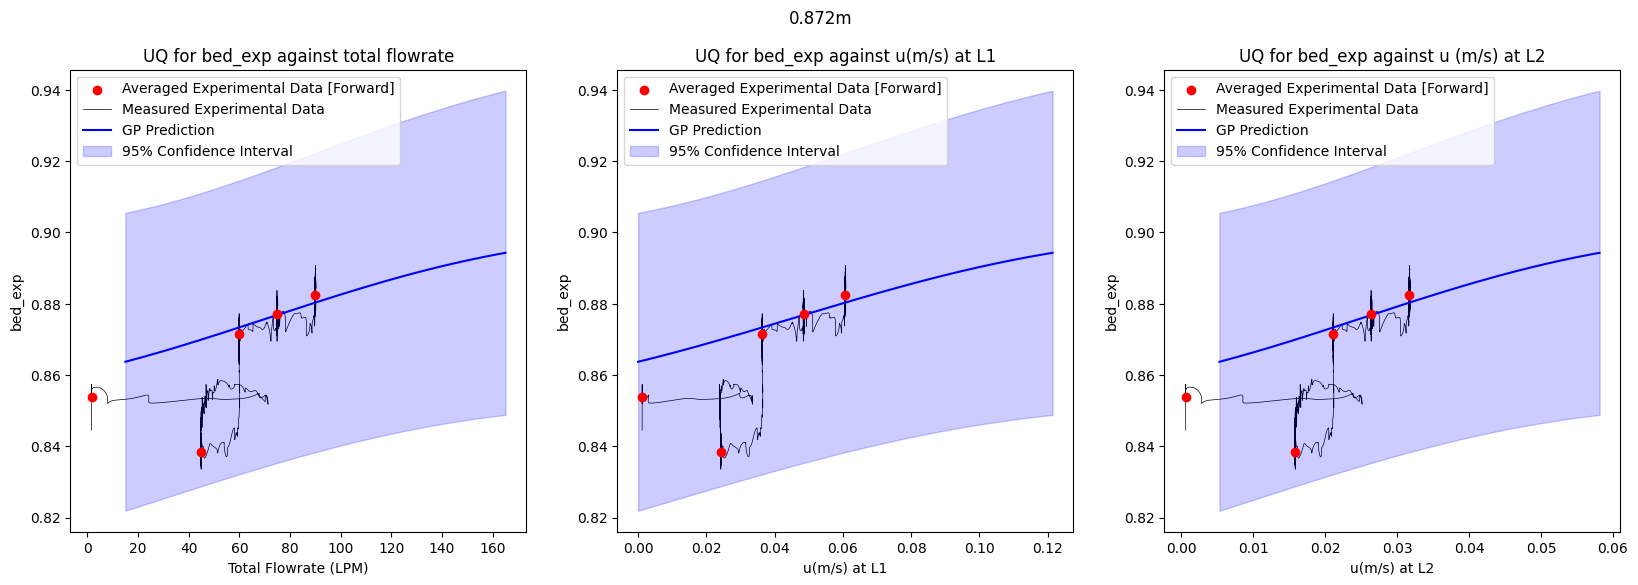

In [676]:
# exp = "956_40_120_50_forward.xlsx"  #
# exp = "808_10_30_15_hysteresis.csv"  #
# exp = "889_35_120_50_forward.csv"
# exp = "740_30_30_15_hysteresis.csv"
# exp = "903_35_120_15_hysteresis.csv"
exp = "872_5_120_50_forward.csv"
# exp = "897_20_120_50_hysteresis.csv"

# Uncertainty quantification and plotting
modelc.uncertainty_quantification_umf(
    X=prediction_inputs,
    test_data=exp,
    x_axis=totalflowrate,
    pred_intercepts=intercepts,
    plot_figure=True,
    plot_forwards_only=True,
    plot_backwards_only=False,
)

In [677]:
# modelc.save("alumina_pressure", True)
modelc.get_hyperparameters()

{'k1': 0.927**2 * RBF(length_scale=[2.3, 1.03]),
 'k2': WhiteKernel(noise_level=0.731),
 'k1__k1': 0.927**2,
 'k1__k2': RBF(length_scale=[2.3, 1.03]),
 'k1__k1__constant_value': np.float64(0.8601870701204314),
 'k1__k1__constant_value_bounds': (1e-05, 100000.0),
 'k1__k2__length_scale': array([2.29824515, 1.03188325]),
 'k1__k2__length_scale_bounds': (1e-05, 100000.0),
 'k2__noise_level': np.float64(0.7309817517262736),
 'k2__noise_level_bounds': (1e-05, 100000.0)}

In [ ]:
modelc.save("alumina_forward_pressure")